# CARpsy — Fine-tuning Qwen3-0.6B con Unsloth (Google Colab A100)

**Modelo:** `unsloth/Qwen3-0.6B` · **Épocas:** 3 · **LoRA rank:** 16 · **Dataset:** canonical_dataset.jsonl (300 ejemplos)

**Cambios respecto al entrenamiento anterior:**
- Dataset canónico: 1 respuesta fija por código, sin aleatoriedad
- Epochs 15 → 3 (evitar catastrophic forgetting)
- Learning rate 2e-4 → 5e-5 (conservar conocimiento del base model)
- LoRA r 8 → 16 con dropout 0.05
- Validación con formato BLUCKTEC (Severity N/3)

Antes de empezar: `Runtime > Change runtime type > A100 GPU`

In [ ]:
# ── CELDA 1 ── Verificar GPU ──────────────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode != 0:
    raise RuntimeError('No GPU encontrada. Ve a Runtime > Change runtime type > T4 GPU')
print(result.stdout)

Thu Jun 18 22:44:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             50W /  400W |     542MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# ── CELDA 2 ── Instalar Unsloth (~2-3 min la primera vez) ─────────────────────
!pip install unsloth --quiet
!pip install --upgrade --no-cache-dir unsloth unsloth_zoo --quiet
print('Unsloth instalado correctamente')

Unsloth instalado correctamente


In [ ]:
# ── CELDA 3 ── Montar Google Drive y configurar directorios ───────────────────
from google.colab import drive, auth
from googleapiclient.discovery import build
import os

drive.mount('/content/drive')
auth.authenticate_user()

FOLDER_ID = '1HNgLVG6b907WOtDxSgP56gcjylsDd0tq'
service   = build('drive', 'v3', cache_discovery=False)
meta      = service.files().get(fileId=FOLDER_ID, fields='name').execute()

BASE_DIR       = f'/content/drive/MyDrive/{meta["name"]}'
CHECKPOINT_DIR = f'{BASE_DIR}/qwen3-0.6b/checkpoints'
ADAPTER_DIR    = f'{BASE_DIR}/qwen3-0.6b/adapter'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(ADAPTER_DIR,    exist_ok=True)

print(f'Google Drive montado')
print(f'Base:         {BASE_DIR}')
print(f'Checkpoints:  {CHECKPOINT_DIR}')
print(f'Adapter:      {ADAPTER_DIR}')

ValueError: Mountpoint must not already contain files

In [ ]:
# ── CELDA 4 ── Cargar canonical_dataset.jsonl ─────────────────────────────────
#
# Dataset canónico: 20 códigos × 15 preguntas = 300 ejemplos
# Cada código tiene UNA respuesta fija en formato BLUCKTEC:
#   {CODE}: {nombre SAE}. Severity N/3 — {acción}. Likely causes: ... {veredicto}.
#
# Estrategia de carga:
#   1. canonical_dataset.jsonl en Drive (ruta esperada)
#   2. Subida manual desde PC
#
import os, json

TRAIN_PATH    = '/content/train.jsonl'
DRIVE_DATASET = f'{BASE_DIR}/canonical_dataset.jsonl'

def count_examples(path):
    with open(path) as f:
        return sum(1 for line in f if line.strip())

# ── Intento 1: canonical_dataset.jsonl en Drive ───────────────────────────────
if os.path.exists(DRIVE_DATASET):
    import shutil
    shutil.copy2(DRIVE_DATASET, TRAIN_PATH)
    n = count_examples(TRAIN_PATH)
    print(f'Dataset canónico cargado desde Drive: {n} ejemplos')

# ── Intento 2: subida manual ──────────────────────────────────────────────────
else:
    print(f'No se encontró {DRIVE_DATASET}')
    print('Sube canonical_dataset.jsonl manualmente:')
    from google.colab import files
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    os.rename(fname, TRAIN_PATH)
    n = count_examples(TRAIN_PATH)
    print(f'Archivo subido: {TRAIN_PATH} ({n} ejemplos)')

# ── Validar formato ───────────────────────────────────────────────────────────
with open(TRAIN_PATH) as f:
    sample = json.loads(f.readline())

assert 'messages' in sample, 'Formato incorrecto: se esperan {"messages": [...]}'
assert len(sample['messages']) == 3, 'Se esperan 3 mensajes: system / user / assistant'

assistant_msg = sample['messages'][2]['content']
assert 'Severity' in assistant_msg, 'Las respuestas deben contener "Severity N/3" — usa canonical_dataset.jsonl'
assert 'Likely causes' in assistant_msg, 'Las respuestas deben contener "Likely causes" — usa canonical_dataset.jsonl'

print(f'Formato OK ({n} ejemplos)')
print(f'Ejemplo de respuesta:\n  {assistant_msg[:150]}...')

No se encontró /content/drive/MyDrive/CARpsy/canonical_dataset.jsonl
Sube canonical_dataset.jsonl manualmente:


Saving canonical_dataset.jsonl to canonical_dataset.jsonl
Archivo subido: /content/train.jsonl (300 ejemplos)
Formato OK (300 ejemplos)
Ejemplo de respuesta:
  P0420: Catalyst System Efficiency Below Threshold (Bank 1). Severity 2/3 — Schedule repair soon; ignoring risks catalytic converter failure and increa...


In [ ]:
# ── CELDA 5 ── Cargar modelo Qwen3-0.6B con Unsloth ──────────────────────────
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 512

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = 'unsloth/Qwen3-0.6B',
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,       # Auto: float16 en T4, bfloat16 en A100
    load_in_4bit   = True,
)

print(f'Modelo: Qwen3-0.6B')
print(f'VRAM usada tras carga: {torch.cuda.memory_allocated()/1024**3:.2f} GB')
print(f'VRAM total disponible: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/576M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/4.91k [00:00<?, ?B/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Modelo: Qwen3-0.6B
VRAM usada tras carga: 0.58 GB
VRAM total disponible: 39.5 GB


In [ ]:
# ── CELDA 6 ── Configurar LoRA ────────────────────────────────────────────────
#
# Cambios respecto al entrenamiento anterior:
#   r 8 → 16     : más capacidad para anclar 20 códigos distintos
#   alpha 16 → 32: escala proporcional (siempre alpha = 2 × r)
#   dropout 0 → 0.05: regularización leve, evita memorización exacta
#
model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    lora_alpha     = 32,
    lora_dropout   = 0.05,
    target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    bias           = 'none',
    use_gradient_checkpointing = 'unsloth',
    random_state   = 42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parámetros entrenables: {trainable:,} ({100*trainable/total:.2f}% del total)')
print(f'VRAM tras LoRA:         {torch.cuda.memory_allocated()/1024**3:.2f} GB')

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Parámetros entrenables: 4,587,520 (1.17% del total)
VRAM tras LoRA:         0.60 GB


In [ ]:
# ── CELDA 7 ── Preparar dataset en formato ChatML ─────────────────────────────
import json
from datasets import Dataset

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

def format_example(example):
    return tokenizer.apply_chat_template(
        example['messages'],
        tokenize=False,
        add_generation_prompt=False,
    )

raw       = load_jsonl(TRAIN_PATH)
formatted = [{'text': format_example(ex)} for ex in raw]
dataset   = Dataset.from_list(formatted)

sample_tokens = [
    len(tokenizer(ex['text'], add_special_tokens=False)['input_ids'])
    for ex in formatted[:300]
]
avg_len = sum(sample_tokens) / len(sample_tokens)
over_limit = sum(1 for t in sample_tokens if t > MAX_SEQ_LENGTH)

print(f'Ejemplos en train:      {len(dataset)}')
print(f'Longitud promedio:      {avg_len:.0f} tokens')
print(f'Ejemplos sobre límite:  {over_limit} / {len(sample_tokens)}')
if over_limit > 0:
    print(f'  WARN: {over_limit} ejemplos superan {MAX_SEQ_LENGTH} tokens y serán truncados')
print(f'\nEjemplo formateado (primeros 300 chars):')
print(dataset[0]['text'][:300])

Ejemplos en train:      300
Longitud promedio:      175 tokens
Ejemplos sobre límite:  0 / 300

Ejemplo formateado (primeros 300 chars):
<|im_start|>system
You are CARpsy, an expert automotive diagnostic assistant specialized in OBD-II fault codes. When given a DTC code, identify it precisely, state its severity, list the most likely causes, and advise whether the vehicle is safe to drive. Always respond in English. Be concise and di


In [ ]:
# ── CELDA 8 ── Entrenar v2 (100 épocas, LR 8e-5) ─────────────────────────────
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported
import glob, shutil, torch

EPOCHS          = 100
BATCH_SIZE      = 4
GRAD_ACCUM      = 4
EFFECTIVE_BATCH = BATCH_SIZE * GRAD_ACCUM   # 16
LEARNING_RATE   = 8e-5
WARMUP_STEPS    = 20

steps_per_epoch = max(1, len(dataset) // EFFECTIVE_BATCH)
total_steps     = steps_per_epoch * EPOCHS

# Limpiar checkpoints anteriores
old_checkpoints = glob.glob(f'{CHECKPOINT_DIR}/checkpoint-*')
if old_checkpoints:
    print(f'Eliminando {len(old_checkpoints)} checkpoints anteriores...')
    for ckpt in old_checkpoints:
        shutil.rmtree(ckpt, ignore_errors=True)
    print('  Checkpoints eliminados. Entrenamiento desde cero.')
else:
    print('No hay checkpoints anteriores. Entrenamiento desde cero.')

print(f'\nConfiguración:')
print(f'  Épocas:           {EPOCHS}')
print(f'  Learning rate:    {LEARNING_RATE}')
print(f'  LoRA r / alpha:   16 / 32')
print(f'  Pasos por época:  {steps_per_epoch}')
print(f'  Pasos totales:    {total_steps}')
print(f'  GPU:              {torch.cuda.get_device_name(0)}')

trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = dataset,
    dataset_text_field = 'text',
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = True,
    args = SFTConfig(
        per_device_train_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = GRAD_ACCUM,
        num_train_epochs            = EPOCHS,
        learning_rate               = LEARNING_RATE,
        weight_decay                = 1e-2,
        lr_scheduler_type           = 'cosine',
        warmup_steps                = WARMUP_STEPS,
        fp16                        = not is_bfloat16_supported(),
        bf16                        = is_bfloat16_supported(),
        logging_steps               = 10,
        save_steps                  = 100,
        save_total_limit            = 2,
        output_dir                  = CHECKPOINT_DIR,
        optim                       = 'adamw_8bit',
        seed                        = 42,
        report_to                   = 'none',
        dataloader_pin_memory       = False,
    ),
)

trainer.train()

Eliminando 2 checkpoints anteriores...
  Checkpoints eliminados. Entrenamiento desde cero.

Configuración:
  Épocas:           100
  Learning rate:    8e-05
  LoRA r / alpha:   16 / 32
  Pasos por época:  18
  Pasos totales:    1800
  GPU:              NVIDIA A100-SXM4-40GB


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/300 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 300 | Num Epochs = 100 | Total steps = 1,900
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 4,587,520 of 600,637,440 (0.76% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,4.171563
20,3.259819
30,2.096437
40,1.233619
50,0.925973
60,0.700968
70,0.517102
80,0.352470
90,0.247003
100,0.180197


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/CARpsy/qwen3-0.6b/checkpoints/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/CARpsy/qwen3-0.6b/checkpoints/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/CARpsy/qwen3-0.6b/checkpoints/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/CARpsy/qwen3-0.6b/checkpoints/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/CARpsy/qwen3-0.6b/checkpoints/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/CARpsy/qwen3-0.6b/checkpoints/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/CARpsy/qwen3-0.6b/checkpoints/checkpoint-700/tokenizer_config.json.
Unslot

TrainOutput(global_step=1900, training_loss=0.10673838118189259, metrics={'train_runtime': 3439.094, 'train_samples_per_second': 8.723, 'train_steps_per_second': 0.552, 'total_flos': 1.4056616361984e+16, 'train_loss': 0.10673838118189259, 'epoch': 100.0})

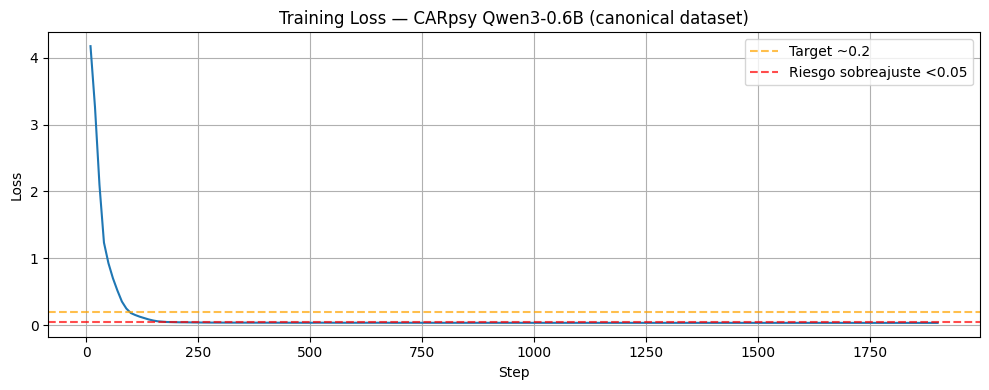

Loss inicial: 4.1716  |  Loss final: 0.0329
WARN: Loss muy bajo — posible sobreajuste. No agregar más épocas.


In [ ]:
# ── CELDA 9 ── Ver curva de pérdida ──────────────────────────────────────────
#
# Señales de éxito:
#   Loss inicial:  ~1.5 – 2.0
#   Loss época 1:  ~0.3 – 0.5
#   Loss final:    ~0.1 – 0.2
#   Si baja de 0.05: posible sobreajuste — no agregar más épocas
#
import matplotlib.pyplot as plt

logs = [x for x in trainer.state.log_history if 'loss' in x]
if logs:
    steps  = [x['step'] for x in logs]
    losses = [x['loss'] for x in logs]

    plt.figure(figsize=(10, 4))
    plt.plot(steps, losses)
    plt.axhline(y=0.2, color='orange', linestyle='--', alpha=0.7, label='Target ~0.2')
    plt.axhline(y=0.05, color='red',    linestyle='--', alpha=0.7, label='Riesgo sobreajuste <0.05')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training Loss — CARpsy Qwen3-0.6B (canonical dataset)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{ADAPTER_DIR}/training_loss.png', dpi=150)
    plt.show()
    print(f'Loss inicial: {losses[0]:.4f}  |  Loss final: {losses[-1]:.4f}')
    if losses[-1] < 0.05:
        print('WARN: Loss muy bajo — posible sobreajuste. No agregar más épocas.')
    elif losses[-1] > 0.4:
        print('WARN: Loss alto — el modelo puede no haber aprendido bien. Revisar dataset.')
    else:
        print('Loss en rango esperado.')
else:
    print('Sin historial de loss (entrenamiento muy corto o reanudado)')

In [ ]:
# ── CELDA 10 ── Guardar adapter LoRA en Google Drive (respaldo ligero) ────────
import os

lora_path = f'{ADAPTER_DIR}/lora-adapter'
model.save_pretrained(lora_path)
tokenizer.save_pretrained(lora_path)

lora_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, filenames in os.walk(lora_path)
    for f in filenames
) / 1024**2
print(f'Adapter LoRA guardado en: {lora_path}')
print(f'Tamaño LoRA:              {lora_size:.1f} MB')

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/lora-adapter/tokenizer_config.json.


Adapter LoRA guardado en: /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/lora-adapter
Tamaño LoRA:              28.4 MB


In [ ]:
# ── CELDA 11b ── Liberar espacio en disco antes del export ──────────────────
import shutil, os, glob

# Borrar caché de HuggingFace
shutil.rmtree('/root/.cache/huggingface', ignore_errors=True)

# Borrar checkpoints (ruta hardcodeada)
for ckpt in glob.glob('/content/drive/MyDrive/*/qwen3-0.6b/checkpoints/checkpoint-*'):
    shutil.rmtree(ckpt, ignore_errors=True)

# Borrar sample_data de Colab
shutil.rmtree('/content/sample_data', ignore_errors=True)

# Ver espacio disponible
print(os.popen('df -h /content').read())
print('Listo. Ahora ejecuta la celda 11.')


Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /

Listo. Ahora ejecuta la celda 11.


In [ ]:
import os, glob

CHECKPOINT_DIR = '/content/drive/MyDrive/CARpsy/qwen3-0.6b/checkpoints'
ckpts = glob.glob(f'{CHECKPOINT_DIR}/checkpoint-*')
print('Checkpoints encontrados:')
for c in sorted(ckpts):
    print(f'  {c}')
if not ckpts:
    print('  (ninguno)')


Checkpoints encontrados:
  (ninguno)


In [ ]:
import subprocess
# Desmontar a nivel de sistema
subprocess.run(['fusermount', '-uz', '/content/drive'], capture_output=True)
# Verificar que quedó vacío
result = subprocess.run(['ls', '/content/drive'], capture_output=True, text=True)
print('Contenido tras desmonte:', result.stdout)


Contenido tras desmonte: MyDrive



In [ ]:
import subprocess

subprocess.run(['umount', '-l', '/content/drive'], capture_output=True)
subprocess.run(['rm', '-rf', '/content/drive'], capture_output=True)
subprocess.run(['mkdir', '/content/drive'], capture_output=True)

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import subprocess
subprocess.run(['ls', '-la', '/content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/lora-adapter/'])

CompletedProcess(args=['ls', '-la', '/content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/lora-adapter/'], returncode=0)

In [ ]:
import subprocess
result = subprocess.run(
    ['ls', '-la', '/content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/lora-adapter/'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)


total 29123
-rw------- 1 root root     1202 Jun 18 21:26 adapter_config.json
-rw------- 1 root root 18380008 Jun 18 21:26 adapter_model.safetensors
-rw------- 1 root root     4905 Jun 18 21:26 chat_template.jinja
-rw------- 1 root root     5246 Jun 18 21:26 README.md
-rw------- 1 root root     5280 Jun 18 21:26 tokenizer_config.json
-rw------- 1 root root 11423114 Jun 18 13:34 tokenizer.json




In [ ]:
from unsloth import FastLanguageModel
from google.colab import auth
from googleapiclient.discovery import build
import os

auth.authenticate_user()
service  = build('drive', 'v3', cache_discovery=False)
FOLDER_ID = '1HNgLVG6b907WOtDxSgP56gcjylsDd0tq'
meta     = service.files().get(fileId=FOLDER_ID, fields='name').execute()
BASE_DIR    = f'/content/drive/MyDrive/{meta["name"]}'
ADAPTER_DIR = f'{BASE_DIR}/qwen3-0.6b/adapter'
LORA_PATH   = f'{ADAPTER_DIR}/lora-adapter'

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = 'unsloth/Qwen3-0.6B',
    max_seq_length = 512,
    dtype          = None,
    load_in_4bit   = False,
)

from peft import PeftModel
model = PeftModel.from_pretrained(model, LORA_PATH)
model = model.merge_and_unload()
print('Modelo base + LoRA fusionados OK')


==((====))==  Unsloth 2026.6.8: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/Qwen3-0.6B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Modelo base + LoRA fusionados OK


In [ ]:
import os, shutil

GGUF_EXPORT_NAME = 'CARpsy-v2-qwen3-0.6b'
GGUF_EXPORT_PATH = f'{ADAPTER_DIR}/{GGUF_EXPORT_NAME}'
FINAL_GGUF_NAME  = 'CARpsy-v2-qwen3-0.6b.Q4_K_M.gguf'
FINAL_GGUF_PATH  = f'{ADAPTER_DIR}/{FINAL_GGUF_NAME}'

print('Exportando — tarda ~15 min...')
model.save_pretrained_gguf(
    GGUF_EXPORT_PATH,
    tokenizer,
    quantization_method = ['f16', 'q4_k_m']
)

gguf_dir = f'{GGUF_EXPORT_PATH}_gguf'
if not os.path.isdir(gguf_dir):
    gguf_dir = ADAPTER_DIR

gguf_candidates = [
    os.path.join(dp, f)
    for dp, _, files in os.walk(gguf_dir)
    for f in files if f.endswith('.gguf') and 'Q4_K_M' in f.upper().replace('-', '_')
]
if not gguf_candidates:
    gguf_candidates = [
        os.path.join(dp, f)
        for dp, _, files in os.walk(gguf_dir)
        for f in files if f.endswith('.gguf')
    ]

src = gguf_candidates[0]
shutil.copy2(src, FINAL_GGUF_PATH)
size_mb = os.path.getsize(FINAL_GGUF_PATH) / 1024**2
print(f'\nListo: {FINAL_GGUF_PATH}')
print(f'Tamaño: {size_mb:.0f} MB')
print(f'Descarga: {FINAL_GGUF_NAME}')


Exportando — tarda ~15 min...
Unsloth: Model is not a PEFT model. Saving directly without LoRA merge...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-v2-qwen3-0.6b/tokenizer_config.json.


Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['f16', 'q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Installing prebuilt llama.cpp b9704 (llama-b9704-bin-ubuntu-x64.tar.gz) - skipping compilation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-v2-qwen3-0.6b_gguf/Qwen3-0.6B.BF16.gguf']
Unsloth: [2] Converting GGUF bf16 into f16. This might take 10 minutes...
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
U

In [ ]:
from google.colab import files
import glob, os

# Buscar el GGUF generado en disco local de Colab
candidates = glob.glob('/content/**/*.gguf', recursive=True) + \
             glob.glob('/root/**/*.gguf', recursive=True)

print('GGUFs encontrados:')
for f in candidates:
    size = os.path.getsize(f) / 1024**2
    print(f'  {f}  ({size:.0f} MB)')


GGUFs encontrados:
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/qwen3-0.6b.Q4_K_M.gguf  (378 MB)
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-qwen3-0.6b.Q4_K_M.gguf  (378 MB)
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-v2-qwen3-0.6b.Q4_K_M.gguf  (378 MB)
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/qwen3-0.6b_gguf/qwen3-0.6b.Q4_K_M.gguf  (378 MB)
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-qwen3-0.6b_gguf/Qwen3-0.6B.F16.gguf  (1143 MB)
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-qwen3-0.6b_gguf/Qwen3-0.6B.Q4_K_M.gguf  (378 MB)
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-qwen3-0.6b_gguf/qwen3-0.6b.F16.gguf  (1143 MB)
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-qwen3-0.6b_gguf/qwen3-0.6b.Q4_K_M.gguf  (378 MB)
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-v2-qwen3-0.6b_gguf/Qwen3-0.6B.F16.gguf  (1143 MB)
  /content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-v2-qwen3-0.6b_gguf/Qwe

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/CARpsy/qwen3-0.6b/adapter/CARpsy-v2-qwen3-0.6b_gguf/Qwen3-0.6B.Q4_K_M.gguf')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── CELDA 11 ── Exportar a GGUF Q4_K_M (CARpsy-v2) ───────────────────────────
import os, shutil, glob
from google.colab import auth
from googleapiclient.discovery import build

# Reconstruir rutas (por si la sesión perdió variables)
auth.authenticate_user()
service  = build('drive', 'v3', cache_discovery=False)
FOLDER_ID = '1HNgLVG6b907WOtDxSgP56gcjylsDd0tq'
meta     = service.files().get(fileId=FOLDER_ID, fields='name').execute()
BASE_DIR     = f'/content/drive/MyDrive/{meta["name"]}'
ADAPTER_DIR  = f'{BASE_DIR}/qwen3-0.6b/adapter'
os.makedirs(ADAPTER_DIR, exist_ok=True)

GGUF_EXPORT_NAME = 'CARpsy-v2-qwen3-0.6b'
GGUF_EXPORT_PATH = f'{ADAPTER_DIR}/{GGUF_EXPORT_NAME}'
FINAL_GGUF_NAME  = 'CARpsy-v2-qwen3-0.6b.Q4_K_M.gguf'
FINAL_GGUF_PATH  = f'{ADAPTER_DIR}/{FINAL_GGUF_NAME}'

print('Exportando CARpsy v2 — fusionando base + LoRA y cuantizando a Q4_K_M...')
print('(f16 primero para evitar corrupción BF16 — tarda ~15 min)')

model.save_pretrained_gguf(
    GGUF_EXPORT_PATH,
    tokenizer,
    quantization_method = ['f16', 'q4_k_m']
)

gguf_dir = f'{GGUF_EXPORT_PATH}_gguf'
if not os.path.isdir(gguf_dir):
    gguf_dir = ADAPTER_DIR

gguf_candidates = [
    os.path.join(dp, f)
    for dp, _, files in os.walk(gguf_dir)
    for f in files if f.endswith('.gguf') and 'Q4_K_M' in f.upper().replace('-', '_')
]
if not gguf_candidates:
    gguf_candidates = [
        os.path.join(dp, f)
        for dp, _, files in os.walk(gguf_dir)
        for f in files if f.endswith('.gguf')
    ]

src = gguf_candidates[0]
shutil.copy2(src, FINAL_GGUF_PATH)

size_mb = os.path.getsize(FINAL_GGUF_PATH) / 1024**2
print(f'\nGGUF generado:  {src}')
print(f'Copiado como:   {FINAL_GGUF_PATH}')
print(f'Tamaño:         {size_mb:.0f} MB')
print(f'\nDescarga: {FINAL_GGUF_NAME}')


Exportando CARpsy v2 — fusionando base + LoRA y cuantizando a Q4_K_M...
(f16 primero para evitar corrupción BF16 — tarda ~15 min)


NameError: name 'model' is not defined

In [ ]:
# ── CELDA 12 ── Validación: 8 casos con formato BLUCKTEC ─────────────────────
#
# Valida que el modelo aprendió el formato canónico:
#   {CODE}: {nombre SAE}. Severity N/3 — {acción}. Likely causes: ... {veredicto}.
#
# Meta: 6/8 o más casos correctos para considerar el modelo apto.
#
import re, torch
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

SYSTEM_PROMPT = (
    "You are CARpsy, an expert automotive diagnostic assistant specialized in OBD-II fault codes. "
    "When given a DTC code, identify it precisely, state its severity, list the most likely causes, "
    "and advise whether the vehicle is safe to drive. "
    "Always respond in English. Be concise and direct. Prioritize safety above all."
)

TEST_CASES = [
    ('P0420', 'I have code P0420 on my Toyota Camry. What does it mean?',
     ['catalyst', 'catalytic', 'converter'], 'warning'),
    ('P0300', 'My car shows P0300. Is it serious?',
     ['misfire', 'cylinder', 'do not drive'], 'critical'),
    ('P0171', 'What does code P0171 mean?',
     ['lean', 'maf', 'causes'], 'warning'),
    ('P0128', 'Code P0128 appeared. Should I worry?',
     ['coolant', 'thermostat', 'causes'], 'warning'),
    ('P0562', 'I have P0562 on my Ford F-150.',
     ['voltage', 'battery', 'do not drive'], 'critical'),
    ('P0087', 'Code P0087 on my Chevrolet Silverado.',
     ['fuel', 'pressure', 'do not drive'], 'critical'),
    ('P0455', 'What is P0455?',
     ['evap', 'leak', 'gas cap'], 'info'),
    ('P0302', 'My Honda Civic shows P0302. Is it safe to drive?',
     ['misfire', 'cylinder', 'do not drive'], 'critical'),
]

def run_inference(question, max_new_tokens=200):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': question},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors='pt'
    ).to('cuda')
    with torch.no_grad():
        out = model.generate(
            inputs, max_new_tokens=max_new_tokens,
            temperature=0.1, top_p=0.9, do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    response = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
    # Eliminar bloque <think> de Qwen3
    response = re.sub(r'<think>.*?</think>', '', response, flags=re.DOTALL).strip()
    return response

passed = 0
for code, question, keywords, severity in TEST_CASES:
    response = run_inference(question)
    resp_lower = response.lower()

    code_ok     = code in response
    severity_ok = 'severity' in resp_lower
    causes_ok   = 'likely causes' in resp_lower or 'causes' in resp_lower
    hits        = [kw for kw in keywords if kw in resp_lower]
    kw_ok       = len(hits) >= 1

    ok = code_ok and severity_ok and causes_ok and kw_ok
    passed += int(ok)
    status = 'PASS' if ok else 'FAIL'

    print(f'[{status}] {code}: {response[:130]}')
    print(f'       code={code_ok} | severity_field={severity_ok} | causes_field={causes_ok} | keywords={hits}')
    print()

print(f'Resultado: {passed}/{len(TEST_CASES)} casos correctos')
if passed >= 6:
    print('Modelo APTO. Descarga qwen3-0.6b.Q4_K_M.gguf desde Google Drive.')
    print('Luego ejecuta: python scripts/06_validate_adapter.py')
elif passed >= 4:
    print('Resultado parcial. Revisa los casos fallidos — considera añadir 1 época más.')
else:
    print('Resultado insuficiente. Verifica que usaste canonical_dataset.jsonl y los hiperparámetros correctos.')